In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files




In [4]:
df = pd.read_excel('AAPL.xlsx')

In [5]:

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
df.dropna(subset=cols, inplace=True)



In [6]:

df['Price_Delta'] = df['Close'] - df['Open']



In [7]:

df['Daily_Return'] = df['Close'].pct_change() * 100



In [8]:

df['Volume_MA'] = df['Volume'].rolling(20).mean()



In [ ]:

Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

anomalies = df[
    (df['Volume'] < Q1 - 1.5 * IQR) |
    (df['Volume'] > Q3 + 1.5 * IQR)
]



In [16]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

anomalies = df[
    (df['Volume'] < Q1 - 1.5 * IQR) |
    (df['Volume'] > Q3 + 1.5 * IQR)
]


returns = df['Daily_Return'].dropna()

print("Mean Return:", returns.mean())
print("Variance:", returns.var())
print("Standard Deviation:", returns.std())

print("\nAnomalous Trading Days:")
print(anomalies[['Date', 'Volume']])

Mean Return: 0.34279419287477125
Variance: 11.565829928271674
Standard Deviation: 3.4008572343266152

Anomalous Trading Days:
          Date     Volume
17  2015-01-26  465842700
21  2015-02-23  368216200
30  2015-04-27  420972300
44  2015-08-03  385000600
47  2015-08-24  500363000
69  2016-01-25  380336500
102 2016-09-12  388228200


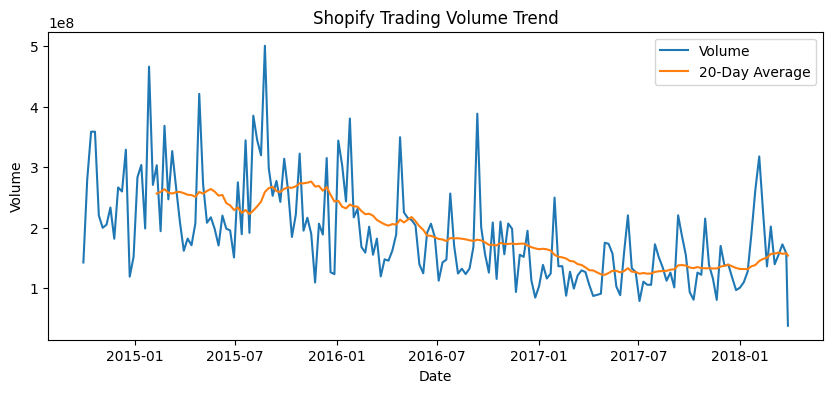

In [12]:

plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Volume'], label='Volume')
plt.plot(df['Date'], df['Volume_MA'], label='20-Day Average')
plt.title("Shopify Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.show()



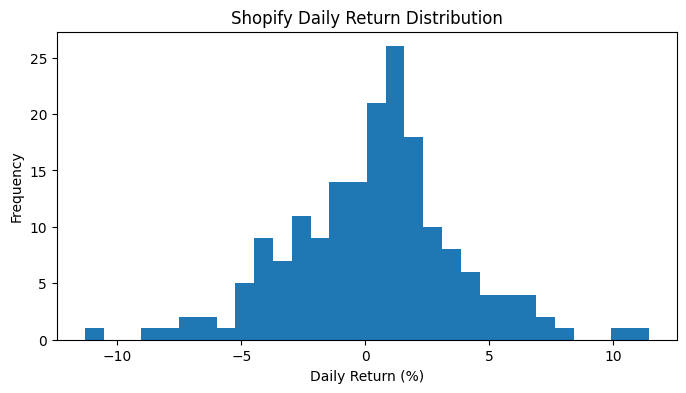

,Date,Open,High,Low,Close,Adj Close,Volume,Price_Delta,Daily_Return,Volume_MA
0,2014-09-29,100.589996,100.690002,98.040001,99.620003,93.514290,142718700,-0.969993,NaN,NaN
1,2014-10-06,99.949997,102.379997,98.309998,100.730003,94.556244,280258200,0.780006,1.114234,NaN
2,2014-10-13,101.330002,101.779999,95.180000,97.669998,91.683792,358539800,-3.660004,-3.037829,NaN
3,2014-10-20,98.320000,105.489998,98.220001,105.220001,98.771042,358532900,6.900001,7.730115,NaN
4,2014-10-27,104.849998,108.040001,104.699997,108.000000,101.380676,220230600,3.150002,2.642082,NaN


In [13]:

plt.figure(figsize=(8,4))
plt.hist(returns, bins=30)
plt.title("Shopify Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

# Display final data
df.head()